In [1]:
import numpy as np
import matplotlib.pyplot as plt


# a) Bestemmelse af værdier for matricen og tegning af robotarmen

In [2]:
# Koordinater for robotarmen
x = np.array([0, 2, 4, 5, 4.8])
y = np.array([0, 5, 5.5, 4, 3.5])

# Opskrivning af de 4 vektorer
a = np.array([2, 5])
b = np.array([4 - 2, 5.5 -5])
c = np.array([5 - 4, 4 - 5.5])
d = np.array([4.8 - 5, 3.5 - 4])


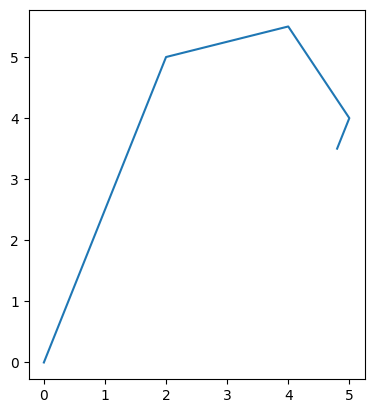

In [3]:
# Tegner robotarmen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x,y)

# b) Bestemmelse af vektoren OP.

På robotarmen ser vi det sidste punkt på armen angivet som P, derfor må OP være vektoren der går fra origo til det punkt. Denne vektor kan bestemmes, som summen af de 4 vektorer, eller som punktet P - Origo.

In [4]:
# Beregner OP's koordinater
OP = [x[4]-0, y[4]-0]
print(OP)

[4.8, 3.5]


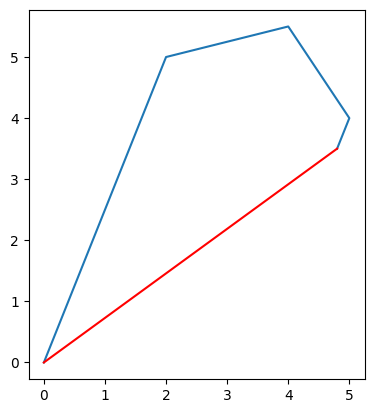

In [5]:
# Tegner robotarmen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x,y)

# Koordinater for OP
OPx = np.array([0, 4.8])
OPy = np.array([0, 3.5])

# Tegner OP
ax.plot(OPx, OPy, color='r')

c) Redegørelse for at en bevægelse i C leddet svarer til at anvende følgende rotationsmatrix R_c på d: 
R_c = [[c, s], [-s, c]]

Vektoren d er en forbindelses vektor mellem punkterne D og P. Hvis man ser på denne som en stedvektor og derefter anvender rotationsvektoren, så vil denne vektor blot ændre vinkel ift origo og dermed punktet D. Derefter kan man sætte den tilbage på robotarmen, og det vil derved ligne at den blot er blevet roteret om punktet D.
Processen ses nedenfor.

In [6]:
# Angivelse af matricen
theta = np.pi/2
cos = np.cos(theta)
sin = np.sin(theta)

R = np.array([[cos, -sin], 
              [sin, cos]])
print(R)

[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]


In [7]:
# d er angivet i opg a
    
# R * d
dny = R @ d
print("d: " + str(d))
print("dny: " + str(dny))

d: [-0.2 -0.5]
dny: [ 0.5 -0.2]


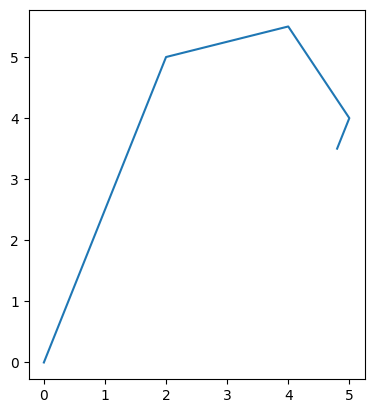

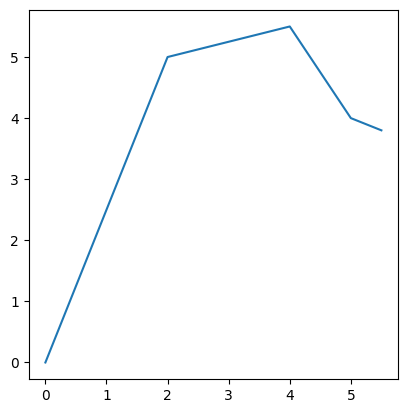

In [8]:
# Laver en ny robotarm, med den nye koordinat for punktet P givet ved punktet C + vektoren d
xny = x.copy()
yny = y.copy()
xny[4] = x[3] + dny[0]
yny[4] = y[3] + dny[1]

# Tegner robotarmen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x,y)

# Tegner robotarmen efter rotationen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(xny,yny)

d) Angivelse af opskrift der bevæger armen i leddet A

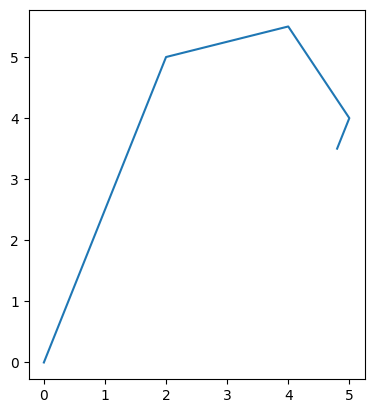

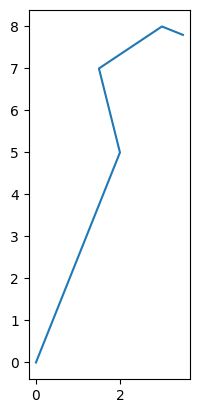

In [9]:
# For at gøre dette, ganger jeg blot rotations matricen på vektorene AB, AC, AP
AB = np.array([x[1] - x[2], y[1] - y[2]])
AC = np.array([x[1] - x[3], y[1] - y[3]])
AD = np.array([x[1] - x[4], y[1] - y[4]])

# Jeg ganger nu matricen på vektorerne
ABny = AB @ R
ACny = AC @ R
ADny = AD @ R

# Jeg beregner punkterne for den nye robotarm
xA = x.copy()
yA = y.copy()
xA[2] = x[1] + ABny[0]
yA[2] = y[1] + ABny[1]
xA[3] = x[1] + ACny[0]
yA[3] = y[1] + ACny[1]
xA[4] = x[1] + ADny[0]
yA[4] = y[1] + ADny[1]

# Tegner robotarmen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x,y)

# Tegner robotarmen efter rotationen
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(xA,yA)

e) Bevis for at rækkefølgen af led vi roterer ikke betyder noget: